# Chapter 6 — Context Window and YaRN

Transformers are trained with a fixed maximum sequence length. When you ask a model to process a sequence *longer* than that limit, it encounters position indices it never saw during training — and accuracy degrades sharply.

This chapter explores three strategies that reshape RoPE’s frequency spectrum so extended position indices map onto familiar angles:

| Strategy | Core idea | Trade-off |
|---|---|---|
| **Linear interpolation** | Divide every frequency by `scale_factor` | Blurs high-frequency (local) structure |
| **NTK-aware scaling** | Increase the base so high-freq dims are nearly untouched | Uniform — can still hurt local patterns |
| **YaRN** | Per-dimension ramp blending linear and NTK, plus attention temperature | Most accurate; two extra hyperparameters |

All three return `(cos, sin)` caches that drop directly into `apply_rope` from Ch-05.

**Prerequisites:** Ch-05 (RoPE `build_rope_cache` / `apply_rope`).

In [1]:
import math
import matplotlib.pyplot as plt
import torch
from transformer_book_lab.rope import apply_rope, build_rope_cache
from transformer_book_lab.rope_scaling import (
    build_rope_cache_linear,
    build_rope_cache_ntk,
    build_rope_cache_yarn,
    yarn_attention_scale,
)

SEQ_LEN  = 32
HEAD_DIM = 16
SCALE    = 4.0   # extend context 4x

cos_base,   sin_base   = build_rope_cache(SEQ_LEN, HEAD_DIM)
cos_linear, sin_linear = build_rope_cache_linear(SEQ_LEN, HEAD_DIM, scale_factor=SCALE)
cos_ntk,    sin_ntk    = build_rope_cache_ntk(SEQ_LEN, HEAD_DIM, scale_factor=SCALE)
cos_yarn,   sin_yarn   = build_rope_cache_yarn(SEQ_LEN, HEAD_DIM, scale_factor=SCALE)
print("All caches shape:", cos_base.shape)

All caches shape: torch.Size([32, 8])


## Frequency Spectrum Visualisation

Each column is one frequency dimension; each row is one sequence position.
The **angle** at position `p`, dimension `i` is `p × θᵢ`.

We compare all four caches at `scale_factor=4` to see how each strategy
reshapes the angle distribution.

C:\Users\fpere\AppData\Local\Temp\claude\ipykernel_6320\158932485.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


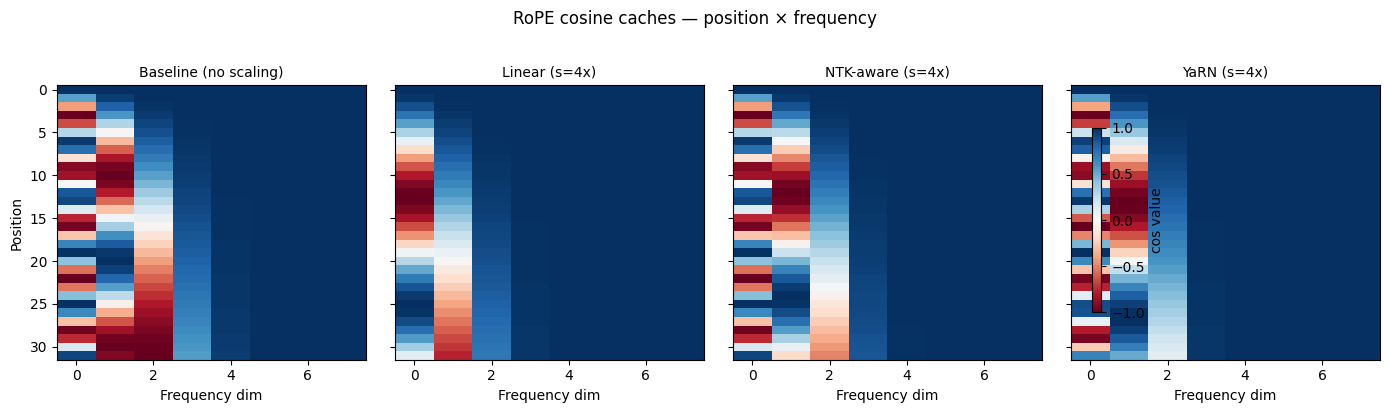

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
configs = [
    (cos_base,   "Baseline (no scaling)"),
    (cos_linear, f"Linear (s={SCALE:.0f}x)"),
    (cos_ntk,    f"NTK-aware (s={SCALE:.0f}x)"),
    (cos_yarn,   f"YaRN (s={SCALE:.0f}x)"),
]
for ax, (cache, title) in zip(axes, configs):
    im = ax.imshow(cache.numpy(), aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Frequency dim")
axes[0].set_ylabel("Position")
fig.colorbar(im, ax=axes, shrink=0.6, label="cos value")
plt.suptitle("RoPE cosine caches — position × frequency", y=1.02)
plt.tight_layout()
plt.show()

## 1 · Linear Interpolation

**Formula:** `θᵢ_linear = θᵢ / s`

Dividing every frequency by `s` is equivalent to pretending each position index is `s` times closer together. Position `p` in the extended context maps to effective position `p / s` in the training range — so no index ever leaves [0, train_len].

**Downside:** high-frequency dimensions (local structure) are compressed the same amount as low-frequency ones. The model’s ability to distinguish adjacent tokens, which relies on large angular differences in high-freq dims, is reduced.

In [3]:
# At position 1 the linear angles are exactly (1/scale) of baseline
angles_base   = torch.atan2(sin_base[1],   cos_base[1])   # (head_dim//2,)
angles_linear = torch.atan2(sin_linear[1], cos_linear[1])

ratio = angles_linear / angles_base
print(f"Angle ratio at pos 1 (should be ~1/{SCALE:.0f} = {1/SCALE:.3f} for all dims):")
print(ratio.numpy().round(4))

# apply_rope works unchanged
q = torch.randn(1, 2, SEQ_LEN, HEAD_DIM)
k = torch.randn(1, 2, SEQ_LEN, HEAD_DIM)
q_rot, k_rot = apply_rope(q, k, cos_linear, sin_linear)
print(f"\nRotated q shape: {q_rot.shape}  (drop-in compatible with apply_rope)")

Angle ratio at pos 1 (should be ~1/4 = 0.250 for all dims):
[0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]

Rotated q shape: torch.Size([1, 2, 32, 16])  (drop-in compatible with apply_rope)


## 2 · NTK-Aware Scaling

**Formula:** `base_ntk = base × s^(d / (d − 2))`

Instead of rescaling frequencies directly, NTK-aware scaling *increases the base* so the resulting frequency formula naturally spreads the spectrum. The key insight: high-frequency dimensions encode local position and should be preserved, while low-frequency dimensions encode global position and can tolerate more compression.

Increasing the base has a larger effect on low-frequency (high-`i`) dimensions and almost no effect on high-frequency (low-`i`) dimensions — exactly the asymmetry we want.

In [4]:
# Compare angle compression by dim: NTK preserves high-freq (dim 0) better than linear
angles_ntk = torch.atan2(sin_ntk[1], cos_ntk[1])

half = HEAD_DIM // 2
print("Angle compression at pos 1 relative to baseline (lower = more compressed):")
print(f"{'Dim':>4}  {'base':>8}  {'linear':>8}  {'ntk':>8}  {'lin%':>7}  {'ntk%':>7}")
for i in range(half):
    b = angles_base[i].item()
    l = angles_linear[i].item()
    n = angles_ntk[i].item()
    print(f"{i:>4}  {b:>8.4f}  {l:>8.4f}  {n:>8.4f}  {100*l/b:>6.1f}%  {100*n/b:>6.1f}%")

Angle compression at pos 1 relative to baseline (lower = more compressed):
 Dim      base    linear       ntk     lin%     ntk%
   0    1.0000    0.2500    1.0000    25.0%   100.0%
   1    0.3162    0.0791    0.2594    25.0%    82.0%
   2    0.1000    0.0250    0.0673    25.0%    67.3%
   3    0.0316    0.0079    0.0175    25.0%    55.2%
   4    0.0100    0.0025    0.0045    25.0%    45.3%
   5    0.0032    0.0008    0.0012    25.0%    37.1%
   6    0.0010    0.0003    0.0003    25.0%    30.5%
   7    0.0003    0.0001    0.0001    25.0%    25.0%


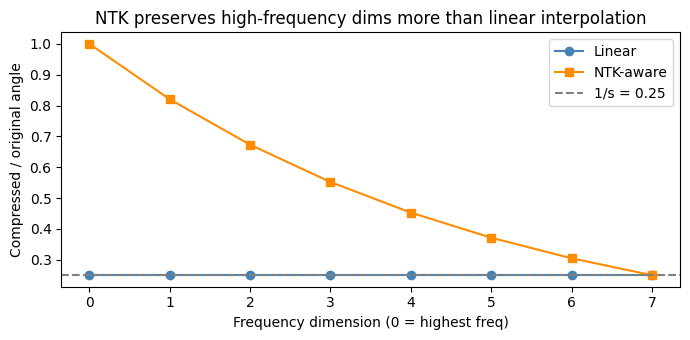

In [5]:
dims = list(range(HEAD_DIM // 2))
linear_ratio = (angles_linear / angles_base).numpy()
ntk_ratio    = (angles_ntk    / angles_base).numpy()

plt.figure(figsize=(7, 3.5))
plt.plot(dims, linear_ratio, "o-", label="Linear",    color="steelblue")
plt.plot(dims, ntk_ratio,    "s-", label="NTK-aware", color="darkorange")
plt.axhline(1/SCALE, color="gray", linestyle="--", label=f"1/s = {1/SCALE:.2f}")
plt.xlabel("Frequency dimension (0 = highest freq)")
plt.ylabel("Compressed / original angle")
plt.title("NTK preserves high-frequency dims more than linear interpolation")
plt.legend()
plt.tight_layout()
plt.show()

## 3 · YaRN — Yet Another RoPE extensioN

**YaRN** (Peng et al. 2023) blends linear and NTK *per dimension* using a ramp function:

```
r_i = clamp( (wavelength_i / s − β_slow) / (β_fast − β_slow), 0, 1 )
θ_yarn_i = r_i · θ_linear_i + (1 − r_i) · θ_ntk_i
```

- **High-freq dims** (small wavelength → `r_i ≈ 1`): use pure **linear** to keep local structure crisp
- **Low-freq dims** (large wavelength → `r_i ≈ 0`): use pure **NTK** for global compression
- **Middle dims**: smooth interpolation between the two

YaRN also applies an **attention temperature** `t = 0.1·ln(s) + 1.0` to attention logits, counteracting the entropy increase from wider position distributions.

In [6]:
# Show the ramp weight per dimension
base_val = 10000.0
half = HEAD_DIM // 2
i_vals = torch.arange(0, half).float()
theta_base_vals = 1.0 / (base_val ** (i_vals / half))
wavelength = 2.0 * math.pi / theta_base_vals

beta_fast, beta_slow = 32.0, 1.0
ramp = torch.clamp(
    (wavelength / SCALE - beta_slow) / (beta_fast - beta_slow), 0.0, 1.0
)

print("Ramp weight r_i per dimension (1=pure linear, 0=pure NTK):")
for i in range(half):
    bar = '#' * int(ramp[i].item() * 20)
    print(f"  dim {i:>2}: wavelength={wavelength[i].item():7.2f}  r={ramp[i].item():.3f}  |{bar:<20}|")

Ramp weight r_i per dimension (1=pure linear, 0=pure NTK):
  dim  0: wavelength=   6.28  r=0.018  |                    |
  dim  1: wavelength=  19.87  r=0.128  |##                  |
  dim  2: wavelength=  62.83  r=0.474  |#########           |
  dim  3: wavelength= 198.69  r=1.000  |####################|
  dim  4: wavelength= 628.32  r=1.000  |####################|
  dim  5: wavelength=1986.92  r=1.000  |####################|
  dim  6: wavelength=6283.19  r=1.000  |####################|
  dim  7: wavelength=19869.18  r=1.000  |####################|


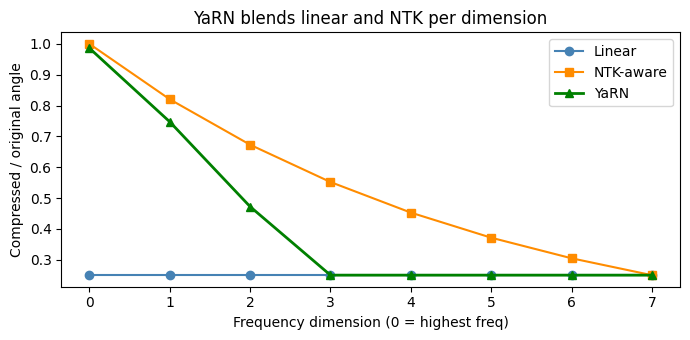

In [7]:
# YaRN angles vs linear and NTK
angles_yarn   = torch.atan2(sin_yarn[1],   cos_yarn[1])
angles_lin_1  = torch.atan2(sin_linear[1], cos_linear[1])
angles_ntk_1  = torch.atan2(sin_ntk[1],    cos_ntk[1])

plt.figure(figsize=(7, 3.5))
plt.plot(dims, (angles_lin_1  / angles_base).numpy(), "o-", label="Linear",    color="steelblue")
plt.plot(dims, (angles_ntk_1  / angles_base).numpy(), "s-", label="NTK-aware", color="darkorange")
plt.plot(dims, (angles_yarn   / angles_base).numpy(), "^-", label="YaRN",      color="green", linewidth=2)
plt.xlabel("Frequency dimension (0 = highest freq)")
plt.ylabel("Compressed / original angle")
plt.title("YaRN blends linear and NTK per dimension")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
t = yarn_attention_scale(SCALE)
print(f"YaRN attention scale at s={SCALE}: {t:.4f}")
print(f"  Formula: 0.1 * ln({SCALE}) + 1.0 = 0.1 * {math.log(SCALE):.4f} + 1.0 = {t:.4f}")
print()
print("Effect: multiply attention logits by this factor before softmax.")
print("This compensates for entropy increase when attending over a wider position range.")

YaRN attention scale at s=4.0: 1.1386
  Formula: 0.1 * ln(4.0) + 1.0 = 0.1 * 1.3863 + 1.0 = 1.1386

Effect: multiply attention logits by this factor before softmax.
This compensates for entropy increase when attending over a wider position range.


## Key Takeaways

- **Why context extension matters:** a trained model sees position angles in a fixed range; positions beyond that produce out-of-distribution angles that degrade quality.

- **Linear interpolation** is the simplest fix — divide every frequency by `s` — but it uniformly compresses all dimensions, blurring local (high-frequency) patterns.

- **NTK-aware scaling** modifies the RoPE base to leave high-frequency dims nearly unchanged while compressing low-frequency ones. A single parameter change, no per-dim computation.

- **YaRN** applies a per-dimension ramp to blend linear (good for local) and NTK (good for global), paired with an attention temperature that corrects for wider attention entropy. It is the most accurate of the three at the cost of two extra hyperparameters (`β_fast`, `β_slow`).

- All three strategies return `(cos, sin)` caches with the same shape and interface as `build_rope_cache`, so they are drop-in replacements for `apply_rope` — no architectural changes required.

- YaRN-style scaling is used in production LLMs (e.g. Mistral, LLaMA 3 long-context variants) without retraining from scratch.

> **Limitation:** a proper evaluation would plot perplexity vs sequence length for a trained model. Here we show geometric properties of the caches. The visual and numerical comparisons accurately illustrate the key trade-offs.

## Final Exercise

Implement a **custom ramp function** for YaRN that uses a *sigmoid* instead of a linear clamp:

```
r_i = sigmoid( (wavelength_i / s − midpoint) / sharpness )
```

where `midpoint` and `sharpness` are tunable parameters.

1. Write `build_rope_cache_yarn_sigmoid(seq_len, head_dim, scale_factor, midpoint=16.0, sharpness=4.0, base=10000.0, device=None)` that replaces the `clamp` ramp with the sigmoid version.
2. Plot the sigmoid ramp weights alongside the original YaRN ramp for the same `head_dim` and `scale_factor`.
3. How does increasing `sharpness` affect the per-dimension blending? What would `sharpness → ∞` converge to?